# CMIP - Exploratory Data Analysis (EDA)

### Investigating:
- Which model and scenario does each file represent?
- What variables, units, and dimensions are available?
- Which years and time intervals are covered?
- Where are values missing?
- Do the datasets use comparable grids and variable definitions?

In [ ]:
# from cmip_utils import Scenario, save_fig, save_table, inspect_mat, assumed_times, RAW, load_grid, nearest_point, to_map

ModuleNotFoundError: No module named 'cmip_utils'

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from cmip_utils import (Scenario, save_fig, save_table, inspect_mat, assumed_times, RAW,
                        load_grid, nearest_point, to_map)

FIG_DIR = "eda"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
inspect_mat(RAW / "SeaMask_WW3.mat")

SeaMask_WW3.mat: MATLAB 7.3 MAT-file
  LAT: MATLAB double 1x1  (h5py (1, 1) float64)
  LON: MATLAB double 1x1  (h5py (1, 1) float64)
  NcFile: MATLAB char 1x16  (h5py (16, 1) uint16)
  Nsea: MATLAB double 1x1  (h5py (1, 1) float64)
  SeaIdx: MATLAB double 142868x1  (h5py (1, 142868) float64)
  SeaJ: MATLAB double 142868x1  (h5py (1, 142868) float64)
  SeaK: MATLAB double 142868x1  (h5py (1, 142868) float64)
  SeaMask: MATLAB logical 720x361  (h5py (361, 720) uint8)
  UseAllTimeSteps: MATLAB logical 1x1  (h5py (1, 1) uint8)
  VarName: MATLAB char 1x2  (h5py (2, 1) uint16)
  lat: MATLAB double 361x1  (h5py (1, 361) float64)
  lon: MATLAB double 720x1  (h5py (1, 720) float64)


#### Display pattern for every figure:

In [ ]:
grid = load_grid(verbose=False)

with Scenario("historical") as hist:
    n = hist.available_steps()
    pts = [10_000, 50_000, 100_000]
    hs = hist.read("hs", pts, slice(0, n))

fig, ax = plt.subplots(figsize=(10, 3))
for i, p in enumerate(pts):
        lat, lon = grid["point_lat"][p], (grid["point_lon"][p] + 180) % 360 - 180
        label = f"{abs(lat):.1f}°{'S' if lat < 0 else 'N'}, {abs(lon):.1f}°{'W' if lon < 0 else 'E'}"
        ax.plot(assumed_times(n), hs[:, i], lw=0.4, label=label)
ax.set(ylabel="hs [m]", title="Significant wave height (time axis assumed 3-hourly from 1985)")
ax.legend()
save_fig(fig, "hs_timeseries_3points", FIG_DIR)
plt.show()

NameError: name 'load_grid' is not defined

In [ ]:
for name in ("historical", "ssp126", "ssp585"):
    with Scenario(name) as s:
        print(s)

Scenario('historical': partial download, 87,656 time steps x 142,868 points, 61,256 steps readable)
Scenario('ssp126': partial download, 87,656 time steps x 142,868 points, 44,640 steps readable)
Scenario('ssp585': partial download, 87,656 time steps x 142,868 points, 41,664 steps readable)


Load the coordinates:

In [ ]:
from cmip_utils import load_grid, nearest_point, to_map
grid = load_grid()

142,868 sea points on a 720 x 361 grid (lon 0 to 359.5, lat -90 to 90)
  OK   SeaIdx matches the grid indices
  OK   every point is sea in SeaMask
  OK   SeaMask has exactly this many sea cells


Draw a map. This is also the real test that point numbers match locations:

saved: fig/eda/hs_map_first_month.png


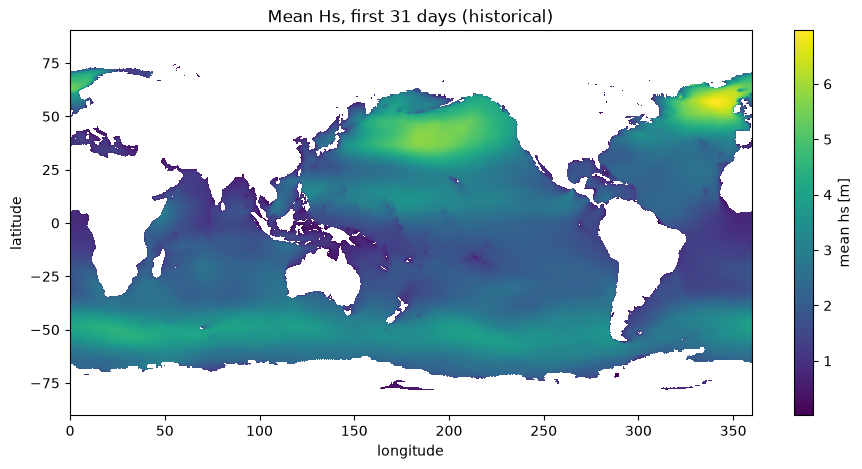

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="Mean of empty slice")   # ice-covered points are all NaN

with Scenario("historical") as hist:
    hs_month = hist.read("hs", slice(None), slice(0, 248))   # all points, first 31 days (~140 MB)

field = to_map(grid, np.nanmean(hs_month, axis=0))
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.pcolormesh(grid["lon"], grid["lat"], field, shading="auto", cmap="viridis")
fig.colorbar(im, ax=ax, label="mean hs [m]")
ax.set(xlabel="longitude", ylabel="latitude",
       title="Mean Hs, first 31 days (historical)")
save_fig(fig, "hs_map_first_month", FIG_DIR)
plt.show()

Find the point closest to any location (longitude can be −180…180 or 0…360):

In [ ]:
p = nearest_point(grid, lat=45.0, lon=-30.0)   # mid North Atlantic

point 127436: lat 45, lon 330 (~0 km from the requested location)
